[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lanzlagman/intro-python-astro-PUP/blob/main/solutions/04_data_visualization_astronomy.ipynb)

> **Solutions copy.** Every **YOUR TURN** cell below is already filled in. Work through `notebooks/` first; read this afterwards.

# Notebook 04: Data Visualization in Astronomy and Astrophysics

**Computational and Data-driven Astrophysics: A Practical Python Workshop**
PUP Physics Society · 15 August 2026

---

You have data from an archive (NB02) and data from a simulation (NB03). This notebook is the
step everyone underestimates: **turning either one into a figure that survives a thesis
defence.**

The distinction that matters is not "pretty vs ugly". It is:

> **a plot** shows you what you already know · **a figure** makes an argument

## Part 0: Setup and data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW = "https://raw.githubusercontent.com/lanzlagman/intro-python-astro-PUP/main/data/"


def load_workshop_data(filename):
    """Local file first, then GitHub. Works identically in Colab and locally."""
    for path in (f"data/{filename}", f"../data/{filename}"):
        if os.path.exists(path):
            print(f"loaded from disk: {path}")
            return pd.read_csv(path)
    print(f"downloading {filename} from GitHub")
    return pd.read_csv(RAW + filename)


# Prefer the file Notebook 02 saved; otherwise fall back to the shipped cache.
if os.path.exists("data/pleiades_query_result.csv"):
    stars = pd.read_csv("data/pleiades_query_result.csv")
    print("using the file you created in Notebook 02")
else:
    stars = load_workshop_data("gaia_pleiades.csv")
    stars = stars[(stars["parallax_over_error"] > 5) & (stars["ruwe"] < 1.4)].copy()

print(f"{len(stars)} stars in the field")

using the file you created in Notebook 02
5180 stars in the field


---
## Part 1: Figure anatomy: `fig, ax`, never bare `plt.plot`

Most tutorials teach `plt.plot(x, y)`. It works, and it is a trap: it draws on whatever
figure happens to be "current", which stops making sense the moment you want two panels,
an inset, or a saved file at a specific size.

The professional idiom names its objects:

```python
fig, ax = plt.subplots()    # fig = the page,  ax = one set of axes on it
ax.plot(x, y)               # draw on THAT axes, explicitly
```

`fig` is the paper. `ax` is a panel. Everything you adjust hangs off one or the other.

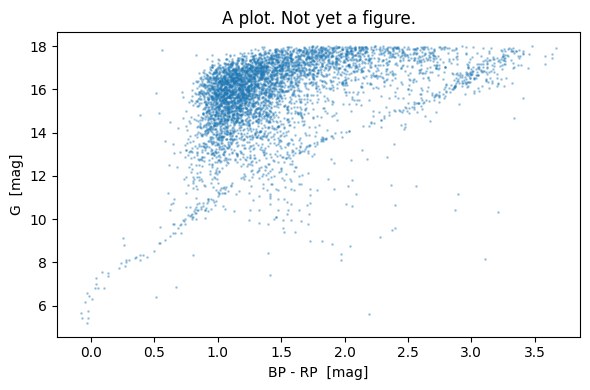

Everything is here and nothing is legible. We fix this in four steps.


In [2]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(stars["bp_rp"], stars["phot_g_mean_mag"], s=1, alpha=0.3)
ax.set_xlabel("BP - RP  [mag]")
ax.set_ylabel("G  [mag]")
ax.set_title("A plot. Not yet a figure.")

plt.tight_layout(); plt.show()

print("Everything is here and nothing is legible. We fix this in four steps.")

---
## Part 2: The colour–magnitude diagram

Determining the effective temperature of every member of a cluster by detailed spectral analysis is slow. Measuring colour indices is fast. With an apparent magnitude and a colour index per star you can build a **colour–magnitude diagram**, and that is what we do here.

Gaia's $BP-RP$ is the modern $B-V$: brightness through a blue filter minus brightness through
a red one. Small = hot and blue. Large = cool and red.

> **Why the y-axis is upside down.** The magnitude scale runs backwards: larger magnitude
> means fainter. Astronomers invert the axis so that *up* means *brighter*, matching physical
> intuition. It is not a stylistic choice: a CMD plotted the other way up is simply wrong, and
> every astronomer in the room will notice within one second.

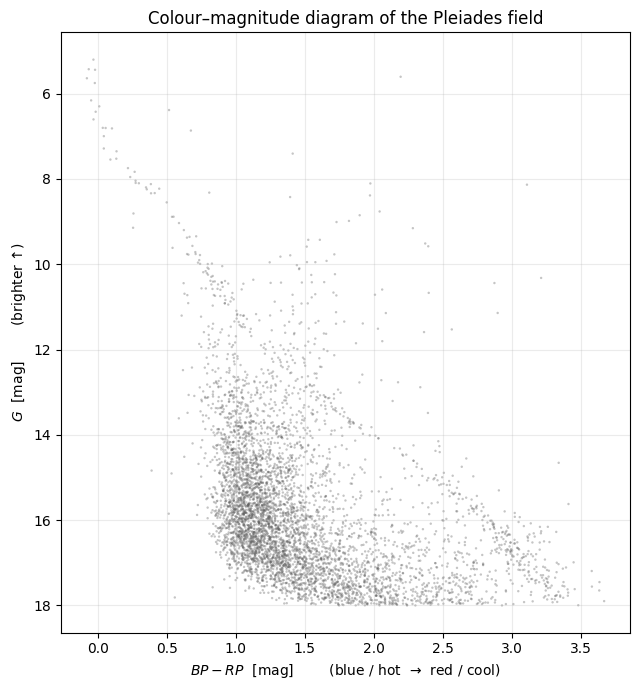

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 7))

ax.scatter(stars["bp_rp"], stars["phot_g_mean_mag"],
           s=3, alpha=0.35, color="0.35", edgecolors="none")

ax.invert_yaxis()                         # <-- brighter = up
ax.set_xlabel("$BP - RP$  [mag]        (blue / hot  →  red / cool)")
ax.set_ylabel("$G$  [mag]        (brighter ↑)")
ax.set_title("Colour–magnitude diagram of the Pleiades field")
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

> **What is the diagonal band?** The **main sequence**, where stars burning hydrogen in their
> cores spend ~90% of their lives. Position along it is set almost entirely by mass.
>
> The scatter around it is the problem this workshop keeps circling: most of these stars are
> *not in the cluster*. They are foreground and background objects at different distances,
> which smears the sequence out.

### From the observer's diagram to the theorist's

Two H–R diagrams get conflated for years:

- **the observer's**: apparent or absolute magnitude against colour. Built from things a
  telescope measures.
- **the theorist's**: luminosity against effective temperature. Built from things a stellar
  model predicts.

Converting between them is the job of the **distance modulus** you wrote in Notebook 01.
Here it is again, doing real work.

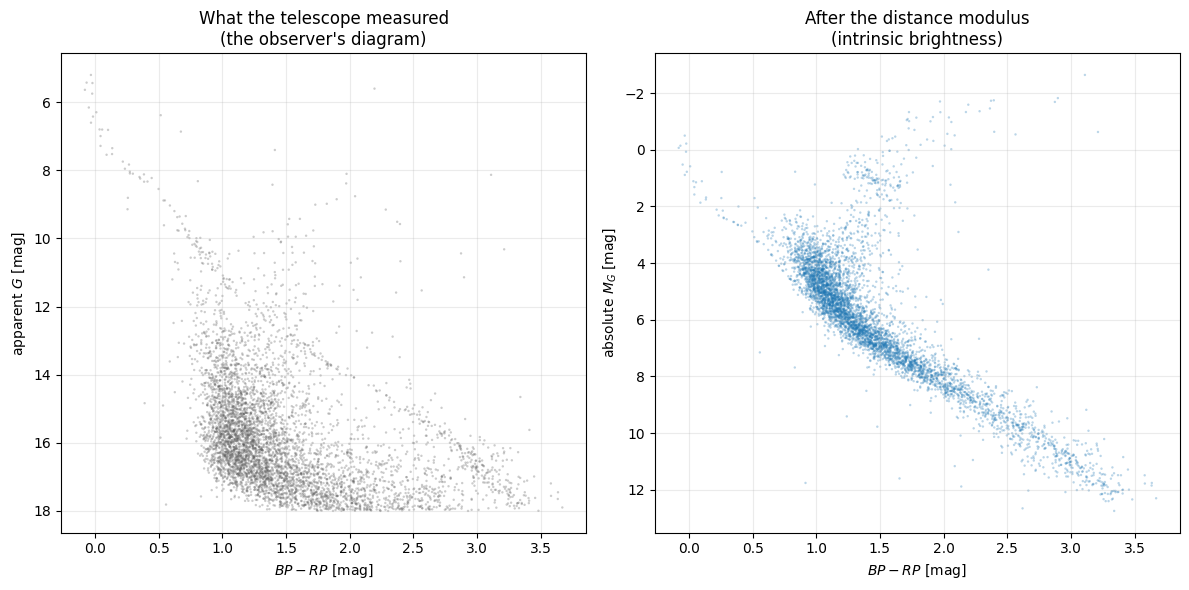

In [4]:
# The distance modulus, exactly as written in Notebook 01
distance_pc = 1000.0 / stars["parallax"]
stars["M_G"] = stars["phot_g_mean_mag"] - 5 * np.log10(distance_pc) + 5

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes[0].scatter(stars["bp_rp"], stars["phot_g_mean_mag"],
                s=3, alpha=0.3, color="0.35", edgecolors="none")
axes[0].invert_yaxis()
axes[0].set_ylabel("apparent $G$ [mag]")
axes[0].set_title("What the telescope measured\n(the observer's diagram)")

axes[1].scatter(stars["bp_rp"], stars["M_G"],
                s=3, alpha=0.3, color="tab:blue", edgecolors="none")
axes[1].invert_yaxis()
axes[1].set_ylabel("absolute $M_G$ [mag]")
axes[1].set_title("After the distance modulus\n(intrinsic brightness)")

for ax in axes:
    ax.set_xlabel("$BP - RP$ [mag]")
    ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

# print("One equation from Notebook 01 moved us from 'how bright it looks'")
# print("to 'how bright it is'. That is the whole distance ladder in one line.")

---
## Part 3: The proper-motion diagram, and the moment the cluster appears

Cluster members share a **common origin**, which has an observational consequence Gaia has
made routine: they share a **common velocity through space**.

Projected on the sky, that velocity is the **proper motion** $(\mu_\alpha, \mu_\delta)$. Field
stars point every which way. Cluster members all point the same way.

A scatter plot of $\mu_\alpha$ against $\mu_\delta$ is called a **vector point diagram**.

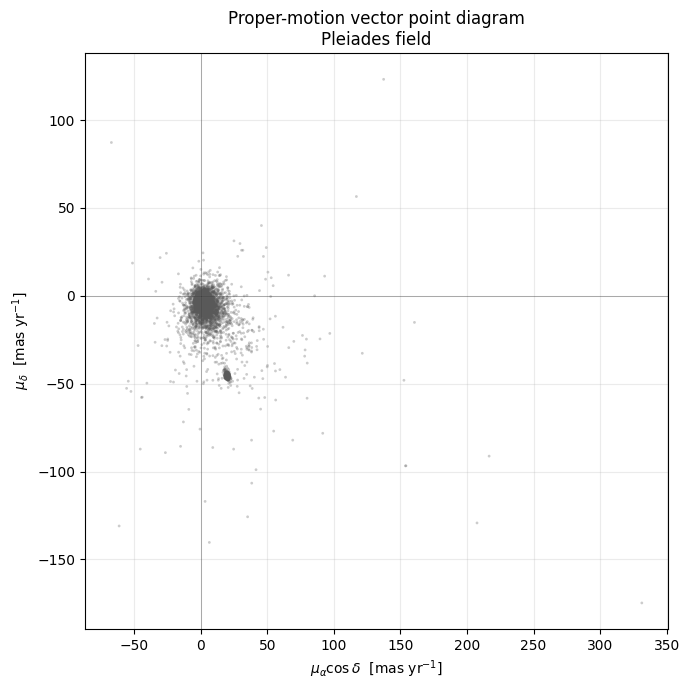

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(stars["pmra"], stars["pmdec"],
           s=4, alpha=0.3, color="0.35", edgecolors="none")

ax.set_xlabel(r"$\mu_\alpha \cos\delta$  [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$  [mas yr$^{-1}$]")
ax.set_title("Proper-motion vector point diagram\nPleiades field")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.axvline(0, color="k", lw=0.5, alpha=0.4)
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

> **There it is.** A dense knot, well away from the origin, sitting in a broad cloud of field
> stars scattered around zero.
>
> That knot is the Pleiades: several hundred stars that formed together about 100 million
> years ago and are still moving together. Nothing in the code knew that.
>
> **This is the actual skill.** Not `scatter()`. Knowing which two of fifteen columns to put on
> the axes.

### ✏️ YOUR TURN

Zoom in on the clump. Set the axis limits to roughly $\mu_\alpha \in [10, 30]$ and
$\mu_\delta \in [-55, -35]$ and see how tight it really is.

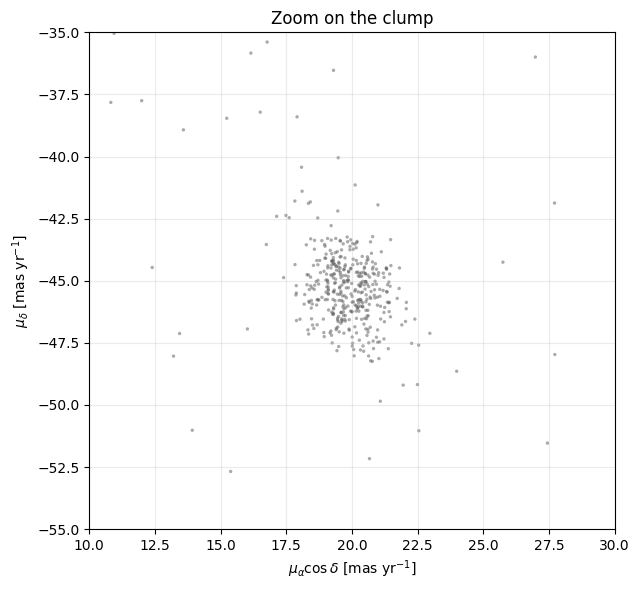

For reference, the median proper motion of the whole field is
  pmra  = 2.9 mas/yr
  pmdec = -5.2 mas/yr


In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(stars["pmra"], stars["pmdec"], s=6, alpha=0.5,
           color="0.35", edgecolors="none")

# YOUR TURN: the clump sits near (+20, -45) mas/yr
ax.set_xlim(10, 30)
ax.set_ylim(-55, -35)

ax.set_xlabel(r"$\mu_\alpha \cos\delta$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Zoom on the clump")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"For reference, the median proper motion of the whole field is")
print(f"  pmra  = {stars['pmra'].median():.1f} mas/yr")
print(f"  pmdec = {stars['pmdec'].median():.1f} mas/yr")

---
## Part 4: Plotting a *model*, not data

Take a box of neutral hydrogen at density $\rho = 10^{-6}$ kg m⁻³, typical of the photosphere
of an A0 star. The **Saha equation** gives a quadratic for the ionised fraction:

$$\left(\frac{N_{II}}{N_t}\right)^2
  + \frac{m_p}{\rho}\left(\frac{2\pi m_e kT}{h^2}\right)^{3/2}e^{-\chi_I/kT}\frac{N_{II}}{N_t}
  - \frac{m_p}{\rho}\left(\frac{2\pi m_e kT}{h^2}\right)^{3/2}e^{-\chi_I/kT} = 0$$

Solve it from 5000 K to 25,000 K and plot the result.

**Why this belongs in a visualisation notebook.** Everything so far has been *measurements*
with scatter. This is a *theoretical curve* with none. Model figures and data figures follow
different rules: a model gets a smooth line and no error bars, and the reader must be able to
tell at a glance which kind of figure they are looking at.

In [7]:
from astropy import constants as const

k_B = const.k_B.value
m_e = const.m_e.value
m_p = const.m_p.value
h   = const.h.value

chi_I = 13.6 * 1.602176634e-19     # hydrogen ionisation energy, joules
rho   = 1e-6                        # kg m^-3, an A0 photosphere

T = np.linspace(5000, 25000, 2000)

# The coefficient that appears twice in the quadratic
A = (m_p / rho) * (2 * np.pi * m_e * k_B * T / h**2)**1.5 * np.exp(-chi_I / (k_B * T))

# Solve x^2 + A x - A = 0, taking the physical (positive) root
frac_ionised = (-A + np.sqrt(A**2 + 4 * A)) / 2

T_half = np.interp(0.5, frac_ionised, T)
print(f"50% ionisation at T = {T_half:.0f} K")
print(f"The standard textbook figure shows 50% near 9600 K.")

50% ionisation at T = 9930 K
The standard textbook figure shows 50% near 9600 K.


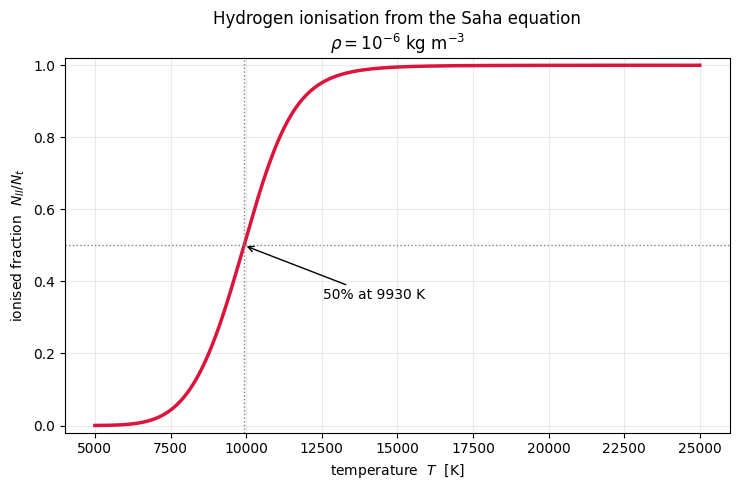

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(T, frac_ionised, color="crimson", lw=2.5)
ax.axhline(0.5, ls=":", color="0.5", lw=1)
ax.axvline(T_half, ls=":", color="0.5", lw=1)
ax.annotate(f"50% at {T_half:.0f} K",
            xy=(T_half, 0.5), xytext=(T_half + 2600, 0.35),
            arrowprops=dict(arrowstyle="->", color="k", lw=1))

ax.set_xlabel("temperature  $T$  [K]")
ax.set_ylabel(r"ionised fraction  $N_{II}/N_{t}$")
ax.set_title("Hydrogen ionisation from the Saha equation\n"
             r"$\rho = 10^{-6}$ kg m$^{-3}$")
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

> ### Read the small disagreement, do not hide it
>
> We get 50% ionisation near **9900 K**; the standard textbook figure shows **9600 K**. That
> gap is not a bug; the two calculations hold *different things* fixed. Ours fixes the **mass
> density** at $10^{-6}$ kg m⁻³; the textbook figure fixes the **electron pressure** at
> $P_e = 20$ N m⁻². Different assumption, slightly different answer.
>
> Noticing a 3% discrepancy and being able to explain *why* is worth more than a figure that
> agrees perfectly for reasons you never checked. **A figure you cannot interrogate is not
> evidence.**
>
> This curve is also why hydrogen Balmer lines peak in A stars near 9500 K: hot enough to
> excite electrons into $n=2$, not so hot that the atom is stripped. The spectral sequence is
> this curve in disguise.

---
## Part 5: The makeover: from plot to figure

Same data as Part 1. Four changes, each of which does one specific job:

1. **Density instead of dots.** Thousands of overlapping points hide structure; `hexbin`
   shows where the stars actually are.
2. **Units in every axis label.** A number with no unit is not a measurement.
3. **A colourbar that means something**, with its own label.
4. **A title that states the finding**, not the file name.

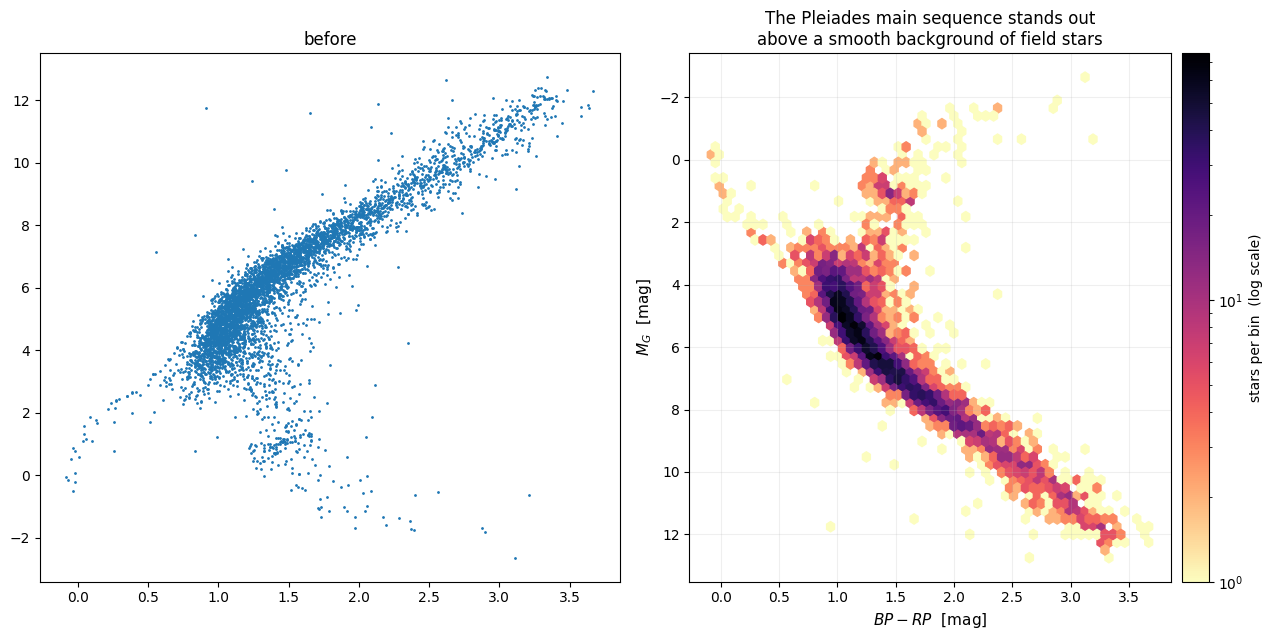

In [9]:
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(13, 6.5))

# ---------- BEFORE ----------
ax_before.scatter(stars["bp_rp"], stars["M_G"], s=1)
ax_before.set_title("before")

# ---------- AFTER ----------
hb = ax_after.hexbin(stars["bp_rp"], stars["M_G"],
                     gridsize=55, cmap="magma_r", mincnt=1, bins="log")

ax_after.invert_yaxis()
ax_after.set_xlabel("$BP - RP$  [mag]", fontsize=11)
ax_after.set_ylabel("$M_G$  [mag]", fontsize=11)
ax_after.set_title("The Pleiades main sequence stands out\n"
                   "above a smooth background of field stars", fontsize=12)
cb = fig.colorbar(hb, ax=ax_after, pad=0.02)
cb.set_label("stars per bin  (log scale)", fontsize=10)
ax_after.grid(alpha=0.2)

plt.tight_layout(); plt.show()

> **Saving figures.** For anything going into a paper, poster or thesis, save vector
> formats: they stay sharp at any zoom:
>
> ```python
> fig.savefig("cmd.pdf", bbox_inches="tight")           # LaTeX
> fig.savefig("cmd.png", dpi=300, bbox_inches="tight")  # slides
> ```
>
> `bbox_inches="tight"` is the difference between a figure with clipped axis labels and one
> without. It is the single most useful keyword in matplotlib.

---
## Stop point: and the hook

Look back at the vector point diagram in Part 3.

**Every person in this room can see the cluster.** You could circle it with your finger.

But **not one line of code in this notebook knows it is there.** No membership list, no count, no boundary. Only a picture in which the answer is obvious to a human and invisible to the program.

That gap: *I can see it, but my code cannot*, is where machine learning enters astronomy. Not as a buzzword: the Gaia catalogue has **1.8 billion** stars and nobody is going to circle them by finger.

**Notebook 05 draws the boundary.**

---
### Sources

Physics and figure conventions follow Carroll & Ostlie, *An Introduction to Modern Astrophysics*, 2nd ed.: §3.2 (The Magnitude Scale), §3.6 (The Color Index), §8.1 (The Formation of Spectral Lines), §8.2 (The Hertzsprung–Russell Diagram), §13.3 (Stellar Clusters). The Saha exercise in Part 4 is adapted from the §8 problem set.

### If you want to go deeper
- Rougier, *Scientific Visualization: Python + Matplotlib*: the figure-anatomy and coordinate-system chapters · <https://github.com/rougier/scientific-visualization-book>
- Pasha & Agostino, *Intermediate matplotlib: Towards Publication-Ready Plots* · <https://prappleizer.github.io/>
- Matplotlib official cheat sheets · <https://matplotlib.org/cheatsheets/>